<a href="https://colab.research.google.com/github/xXElGrisXx/Repositorio_google_colab/blob/main/Lab01_EDA_Chura_Miguel.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Nombre del dataset: Online Food Delivery Dataset

Autor o publicador: Srimathy Sivanessan

Enlace: https://www.kaggle.com/datasets/srisyra02/online-food-ordering-dataset

Archivo seleccionado: online food delivery dataset.csv

Unidad de análisis: Cada fila representa la experiencia y características de un cliente en el servicio de entrega de comida.

Justificación: Elegí esta fuente para analizar los factores que influyen en la satisfacción y el tipo de cliente en servicios de entrega de comida.

Pregunta inicial: Me interesa explorar la relación entre las características demográficas (edad, género, estado civil, ingresos, etc.) y el tipo de cliente o el feedback de los clientes.

Licencia o condiciones de uso: Attribution 4.0 International (CC BY 4.0)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
sns.set_theme(style="whitegrid")
print("Librerias cargadas correctamente")

Librerias cargadas correctamente


In [ ]:

from google.colab import files
archivos_subidos = files.upload()
nombre_csv = next(iter(archivos_subidos))
print("Archivo seleccionado:", nombre_csv)


Saving online food delivery dataset.csv to online food delivery dataset (1).csv
Archivo seleccionado: online food delivery dataset (1).csv


In [ ]:
df = pd.read_csv(nombre_csv, sep=",", encoding='cp1252')
print("Dataset cargado correctamente")

Dataset cargado correctamente


In [ ]:
filas, columnas = df.shape
print("Cantidad de filas:", filas)
print("Cantidad de columnas:", columnas)


Cantidad de filas: 388
Cantidad de columnas: 14


El dataset contiene 285 filas y 14 columnas. Cada fila representa la experiencia y características de un cliente en el servicio de entrega de comida.

In [ ]:
display(df.head())
display(df.tail())
display(df.sample(n=min(10, len(df)), random_state=42))

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.98,77.60,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.98,77.58,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.96,77.66,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.95,77.56,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.98,77.55,560010,Yes,Positive,Yes


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
383,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.98,77.60,560001,Yes,Positive,Yes
384,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.99,77.71,560048,Yes,Positive,Yes
385,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.98,77.55,560010,Yes,Positive,Yes
386,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,Regular,12.98,77.58,560009,Yes,Positive,Yes
387,23,Male,Single,Student,No Income,Post Graduate,5,Frequent,12.90,77.58,560078,Yes,Positive,Yes


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
271,21,Female,Single,Employee,Below Rs.10000,Graduate,2,Regular,12.99,77.56,560021,No,Negative,No
46,24,Female,Single,Student,No Income,Post Graduate,3,Regular,12.98,77.58,560009,Yes,Positive,Yes
167,24,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.99,77.60,560051,Yes,Positive,Yes
42,23,Male,Single,Student,No Income,Post Graduate,4,Frequent,12.99,77.56,560021,Yes,Positive,Yes
349,29,Male,Married,Employee,25001 to 50000,Graduate,4,Frequent,12.93,77.62,560034,No,Negative,No
181,23,Male,Single,Student,Below Rs.10000,Graduate,3,Regular,12.87,77.52,560109,Yes,Negative,Yes
153,21,Male,Single,Student,No Income,Graduate,2,Regular,12.96,77.63,560007,Yes,Positive,Yes
33,22,Female,Single,Student,10001 to 25000,Post Graduate,5,Frequent,12.98,77.55,560010,Yes,Positive,Yes
116,31,Female,Married,House wife,No Income,School,5,Frequent,13.03,77.54,560022,Yes,Positive,Yes
148,32,Male,Married,Employee,10001 to 25000,Graduate,4,Frequent,12.98,77.64,560038,Yes,Positive,Yes


Actualmente, el cuaderno carga el "Online Food Delivery Dataset", que inicialmente constaba de 388 filas y 14 columnas. Se eliminaron registros duplicados, resultando en un DataFrame de 285 filas. No se encontraron valores nulos en ninguna columna.

La mayoría de los nombres de columna son claros, pero 'Unnamed: 13' y la ausencia de un identificador único requieren atención. Las columnas fueron clasificadas en numéricas y categóricas para facilitar el análisis.

Las primeras exploraciones revelan una concentración de clientes jóvenes (22-25 años) y un predominio de feedback positivo, aunque los clientes 'Regular' también contribuyen significativamente al feedback negativo.

In [ ]:
print("Columnas disponibles:")
for numero, columna in enumerate(df.columns, start=1):
    print(numero, "-", columna)

Columnas disponibles:
1 - Age
2 - Gender
3 - Marital Status
4 - Occupation
5 - Monthly Income
6 - Educational Qualifications
7 - Family size
8 - Customer Type
9 - latitude
10 - longitude
11 - Pin code
12 - Output
13 - Feedback
14 - Unnamed: 13


Columna que parece identificar cada registro:

No hay una columna única explícita que actúe como un identificador de registro.

Una combinación de FECHA_CORTE, REGIÓN, ACTIVIDAD_ECONÓMICA y SEXO podría servir para identificar un evento particular, pero no es un ID simple.

Dos columnas numéricas con significado analítico:

    ANIOS: Representa el año en que ocurrió el evento y es directamente analítico para tendencias temporales.

    FECHA_CORTE: Aunque numérico (entero), se puede convertir a formato de fecha para análisis de series de tiempo y representa el día de corte del dato.

Una columna categórica con grupos comprensibles:

    SEXO: Categorías claras como 'HOMBRE' y 'MUJER'.
    REGIÓN: Representa ubicaciones geográficas y es fácilmente comprensible como categoría.

Una posible columna de fecha:

    FECHA_CORTE: Claramente una fecha en formato numérico YYYYMMDD que puede ser transformada en tipo datetime.

Una columna cuyo significado necesite consultar en Kaggle:

    V_DESCATOCU: Aunque sugiere 'descripción de categoría ocupacional', sus posibles valores y su granularidad serían cruciales para un análisis preciso, por lo que una documentación de Kaggle sería muy útil.

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

In [ ]:
resumen_columnas = pd.DataFrame({
"tipo_pandas": df.dtypes.astype(str),
"datos_presentes": df.notna().sum(),
"datos_nulos": df.isna().sum(),
"valores_unicos": df.nunique(dropna=True)
})
resumen_columnas

,tipo_pandas,datos_presentes,datos_nulos,valores_unicos
Age,int64,388,0,16
Gender,object,388,0,2
Marital Status,object,388,0,3
Occupation,object,388,0,4
Monthly Income,object,388,0,5
Educational Qualifications,object,388,0,5
Family size,int64,388,0,6
Customer Type,object,388,0,3
latitude,float64,388,0,77
longitude,float64,388,0,76


In [ ]:
columnas_numericas = df.select_dtypes(
include=np.number
).columns.tolist()
columnas_categoricas = df.select_dtypes(
include=["object", "category", "bool"]
).columns.tolist()
print("Columnas numericas:", columnas_numericas)
print("Columnas categoricas:", columnas_categoricas)


Columnas numericas: ['Age', 'Family size', 'latitude', 'longitude', 'Pin code']
Columnas categoricas: ['Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Customer Type', 'Output', 'Feedback', 'Unnamed: 13']


Se han identificado 5 columnas numéricas: Age, Family size, latitude, longitude y Pin code. Asimismo, se encontraron 9 columnas categóricas: Gender, Marital Status, Occupation, Monthly Income, Educational Qualifications, Customer Type, Output, Feedback y Unnamed: 13. Un buen ejemplo de una columna cuyo tipo de dato de Pandas podría no coincidir con su significado es 'Pin code'. Aunque Pandas la clasifica como un tipo entero (int64), semánticamente funciona más como un identificador geográfico o una categoría, y no como un valor cuantitativo sobre el que se deban realizar operaciones aritméticas directas.

In [ ]:
resumen_nulos = pd.DataFrame({
"cantidad_nulos": df.isnull().sum(),
"porcentaje_nulos": (df.isnull().mean() *
100).round(2)
})
resumen_nulos = resumen_nulos.sort_values(
by="porcentaje_nulos",
ascending=False
)
resumen_nulos

,cantidad_nulos,porcentaje_nulos
Age,0,0.00
Gender,0,0.00
Marital Status,0,0.00
Occupation,0,0.00
Monthly Income,0,0.00
Educational Qualifications,0,0.00
Family size,0,0.00
Customer Type,0,0.00
latitude,0,0.00
longitude,0,0.00


In [ ]:
columnas_con_nulos = resumen_nulos[
resumen_nulos["cantidad_nulos"] > 0
]
columnas_con_nulos

,cantidad_nulos,porcentaje_nulos


En el dataset actual, no se encontraron valores nulos en ninguna de las columnas, por lo que ninguna columna tiene valores nulos y, consecuentemente, el porcentaje de nulos para todas es del 0%. Esto sugiere un dataset muy limpio o pre-procesado. Una pregunta para la fuente podría ser: "¿Qué procesos de recopilación o limpieza de datos se implementaron para asegurar la completa ausencia de valores nulos en todas las columnas?", ya que la exhaustividad de los datos es notable.

In [ ]:
cantidad_duplicados = df.duplicated().sum()
porcentaje_duplicados = cantidad_duplicados / len(df) * 100
print("Filas duplicadas:", cantidad_duplicados)
print("Porcentaje duplicado:", round(porcentaje_duplicados, 2), " %")

Filas duplicadas: 103
Porcentaje duplicado: 26.55  %


In [ ]:
df[df.duplicated(keep=False)].head(10)


,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.96,77.66,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.95,77.56,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.98,77.55,560010,Yes,Positive,Yes
5,27,Female,Married,Employee,More than 50000,Post Graduate,2,Regular,12.93,77.68,560103,Yes,Positive,Yes
6,22,Male,Single,Student,No Income,Graduate,3,Regular,12.98,77.58,560009,Yes,Positive,Yes
7,24,Female,Single,Student,No Income,Post Graduate,3,Regular,12.98,77.61,560042,Yes,Positive,Yes
8,23,Female,Single,Student,No Income,Post Graduate,2,Regular,12.98,77.60,560001,Yes,Positive,Yes
9,23,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.99,77.71,560048,Yes,Positive,Yes
10,22,Female,Single,Student,No Income,Post Graduate,5,Frequent,12.98,77.55,560010,Yes,Positive,Yes
11,23,Male,Single,Student,Below Rs.10000,Post Graduate,2,Regular,12.98,77.58,560009,Yes,Negative,Yes


Sí, existen duplicados exactos en el conjunto de datos. Se han identificado 103 filas duplicadas, lo que representa un 26.55% del total inicial de 388 registros. Es crucial entender que un duplicado no siempre es un error; podría haber eventos válidos con información idéntica, especialmente en conjuntos de datos donde los eventos no tienen un identificador único inherente. Para determinar si estos duplicados son errores o datos válidos, se necesita conocer la unidad de análisis específica del estudio (qué representa cada fila) y las reglas de la fuente de datos. Sin esta información adicional, no se puede concluir automáticamente que sean erróneos, pero sí es importante considerarlos.

In [ ]:
valores_diferentes = df.nunique(dropna=False).sort_values()
valores_diferentes


,0
Gender,2
Unnamed: 13,2
Feedback,2
Output,2
Customer Type,3
Marital Status,3
Occupation,4
Educational Qualifications,5
Monthly Income,5
Family size,6


In [ ]:
print(columnas_numericas)


['Age', 'Family size', 'latitude', 'longitude', 'Pin code']


In [ ]:
if columnas_numericas:
  resumen_numerico = df[columnas_numericas].describe().T
  display(resumen_numerico)
else:
  print("El dataset no tiene columnas numericas detectadas")

,count,mean,std,min,25%,50%,75%,max
Age,388.00,24.63,2.98,18.00,23.00,24.00,26.00,33.00
Family size,388.00,3.28,1.35,1.00,2.00,3.00,4.00,6.00
latitude,388.00,12.97,0.04,12.87,12.94,12.98,13.00,13.10
longitude,388.00,77.60,0.05,77.48,77.57,77.59,77.63,77.76
Pin code,388.00,"560,040.11",31.40,"560,001.00","560,010.75","560,033.50","560,068.00","560,109.00"


In [ ]:
if columnas_numericas:
  comparacion_centro = pd.DataFrame({
    "media": df[columnas_numericas].mean(),
    "mediana": df[columnas_numericas].median(),
    "desviacion_estandar": df[columnas_numericas].std(),
    "minimo": df[columnas_numericas].min(),
    "maximo": df[columnas_numericas].max()
  })
  display(comparacion_centro)


,media,mediana,desviacion_estandar,minimo,maximo
Age,24.63,24.00,2.98,18.00,33.00
Family size,3.28,3.00,1.35,1.00,6.00
latitude,12.97,12.98,0.04,12.87,13.10
longitude,77.60,77.59,0.05,77.48,77.76
Pin code,"560,040.11","560,033.50",31.40,"560,001.00","560,109.00"


Al analizar las columnas numéricas, es crucial comparar la media y la mediana para entender la distribución de los datos. Si estos valores están muy alejados, la distribución podría ser asimétrica o contener valores atípicos. Por ejemplo, en el dataset, para la columna 'Age', la media es 24.63 y la mediana es 24.00; y para 'Family size', la media es 3.28 y la mediana es 3.00. En ambos casos, la cercanía entre la media y la mediana sugiere una distribución relativamente simétrica, sin valores extremos significativos que distorsionen la tendencia central. Es importante recordar que si una columna numérica funciona como un identificador, como 'Pin code', su media no debe interpretarse analíticamente aunque Pandas la calcule.

In [ ]:
if columnas_numericas:
  tabla_percentiles = df[columnas_numericas].quantile(
    [0.00, 0.05, 0.25, 0.50, 0.75, 0.95, 1.00]
  ).T
  tabla_percentiles.columns = [
    "min", "p05", "p25", "p50_mediana",
    "p75", "p95", "max"
  ]
  display(tabla_percentiles)


,min,p05,p25,p50_mediana,p75,p95,max
Age,18.00,21.00,23.00,24.00,26.00,31.00,33.00
Family size,1.00,1.00,2.00,3.00,4.00,6.00,6.00
latitude,12.87,12.90,12.94,12.98,13.00,13.06,13.10
longitude,77.48,77.54,77.57,77.59,77.63,77.68,77.76
Pin code,"560,001.00","560,003.00","560,010.75","560,033.50","560,068.00","560,096.00","560,109.00"


Para una columna numérica significativa como 'Age' (Edad), podemos observar lo siguiente: El 25% de los registros tiene una edad menor o igual a 23 años, lo que nos da una idea del cuarto inferior de la distribución. La mediana de la edad es 24 años, mientras que la media es 24.63 años; la cercanía de estos valores sugiere una distribución relativamente simétrica sin un sesgo marcado. Finalmente, entre el percentil 95 (30 años) y el valor máximo (33 años) existe una diferencia de 3 años, lo que podría indicar que no hay edades excesivamente atípicas en el extremo superior de la distribución o que los datos están bastante concentrados en un rango específico. Es fundamental no interpretar la media de columnas que, aunque numéricas, actúen como identificadores, como 'Pin code'.

In [ ]:
if columnas_categoricas:
  resumen_categorico = df[columnas_categoricas].describe().T
  display(resumen_categorico)
else:
  print("No se detectaron columnas categoricas")


,count,unique,top,freq
Gender,388,2,Male,222
Marital Status,388,3,Single,268
Occupation,388,4,Student,207
Monthly Income,388,5,No Income,187
Educational Qualifications,388,5,Graduate,177
Customer Type,388,3,Regular,218
Output,388,2,Yes,301
Feedback,388,2,Positive,317
Unnamed: 13,388,2,Yes,301


In [ ]:
print(columnas_categoricas)
# Cambia el indice si la primera columna no es adecuada.
columna_categorica = columnas_categoricas[0]
print("Columna elegida:", columna_categorica)


['Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Customer Type', 'Output', 'Feedback', 'Unnamed: 13']
Columna elegida: Gender


In [ ]:
frecuencia = df[columna_categorica].value_counts(
dropna=False
)
porcentaje = df[columna_categorica].value_counts(
dropna=False,
normalize=True
).mul(100).round(2)
tabla_frecuencias = pd.DataFrame({
"cantidad": frecuencia,
"porcentaje": porcentaje
})
tabla_frecuencias.head(15)

,cantidad,porcentaje
Gender,,
Male,222,57.22
Female,166,42.78


Al observar la distribución de la columna categórica 'Gender', la categoría más frecuente es 'Male', representando un 57.22% del total de registros. Aunque 'Male' es mayoritario, la categoría 'Female' también tiene una presencia significativa con un 42.78%, lo que sugiere que no hay una dominancia abrumadora de una sola categoría en términos de género, sino una distribución relativamente equilibrada. En cuanto a la calidad de los datos, para la columna 'Gender' no se aprecian problemas de inconsistencias en la escritura o capitalización, ya que solo se han identificado dos valores únicos ('Male' y 'Female'). Esto indica que los datos están limpios en este aspecto, evitando ambigüedades como 'Male', 'MALE' o 'male' que requerirían normalización.

In [ ]:
print(columnas_numericas)
# Cambia el indice para elegir una variable significativa.
columna_numerica = columnas_numericas[1]
print("Columna elegida:", columna_numerica)

['Age', 'Family size', 'latitude', 'longitude', 'Pin code']
Columna elegida: Family size


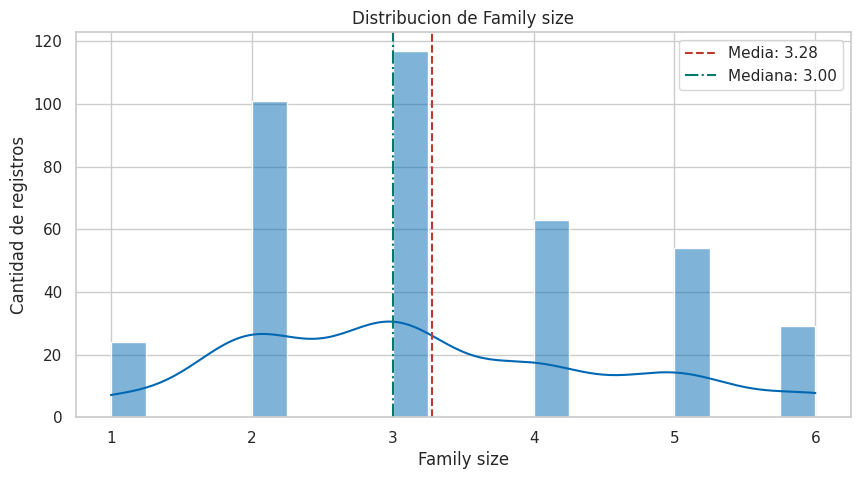

In [ ]:
media = df[columna_numerica].mean()
mediana = df[columna_numerica].median()
plt.figure(figsize=(10, 5))
sns.histplot(
  data=df,
  x=columna_numerica,
  bins=20,
  kde=True,
  color="#0068B3"
)
plt.axvline(
  media,
  color="#C0392B",
  linestyle="--",
  label=f"Media: {media:.2f}"
)
plt.axvline(
  mediana,
  color="#007A6A",
  linestyle="-.",
  label=f"Mediana: {mediana:.2f}"
)
plt.title(f"Distribucion de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.ylabel("Cantidad de registros")
plt.legend()
plt.show()

La mayoría de los valores de tamaño familiar se concentran entre 2 y 3. La forma de la distribución parece aproximadamente simétrica, con una ligera inclinación hacia tamaños familiares más grandes. Sí, la media (3.28) y la mediana (3.00) están bastante cercanas. No se observan zonas aisladas ni valores extremadamente alejados de la tendencia principal. La forma de la distribución se ve influenciada por los límites naturales de los tamaños de familia y su medición en números enteros.

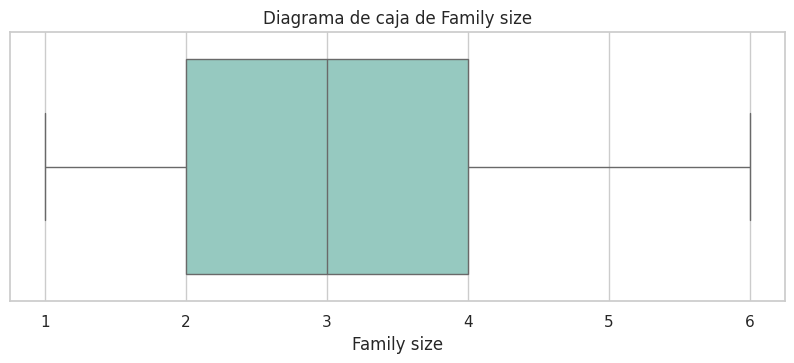

In [ ]:
plt.figure(figsize=(10, 3.5))
sns.boxplot(
  x=df[columna_numerica],
  color="#8ED1C6"
)
plt.title(f"Diagrama de caja de {columna_numerica}")
plt.xlabel(columna_numerica)
plt.show()


Al comparar el diagrama de caja de 'Family size' con los percentiles calculados, observamos una excelente coincidencia. La caja central abarca desde el percentil 25 (2 personas) hasta el percentil 75 (4 personas), con la mediana claramente marcada en 3. Los bigotes del diagrama se extienden hasta los valores mínimo (1 persona) y máximo (6 personas), lo que confirma la ausencia de puntos atípicos o muy alejados en esta variable. Esto es importante porque, si hubiéramos detectado puntos fuera de los bigotes, esas observaciones deberían investigarse. Dichos valores extremos no son automáticamente errores; podrían ser casos poco frecuentes pero válidos, o datos cruciales para el análisis, en lugar de ser simplemente eliminados.

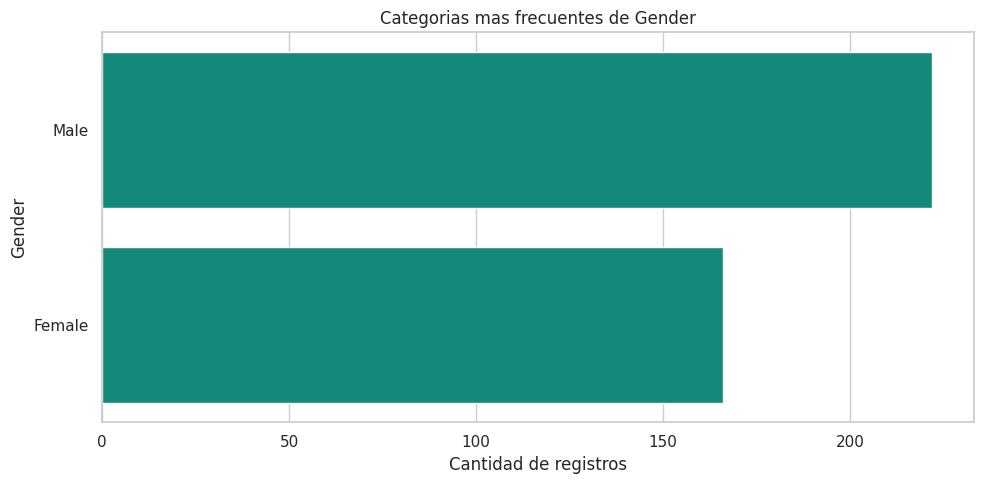

In [ ]:
top_categorias = df[columna_categorica].value_counts(
  dropna=False
).head(10)
plt.figure(figsize=(10, 5))
sns.barplot(
  x=top_categorias.values,
  y=top_categorias.index.astype(str),
  color="#009C88"
)
plt.title(f"Categorias mas frecuentes de {columna_categorica}")
plt.xlabel("Cantidad de registros")
plt.ylabel(columna_categorica)
plt.tight_layout()
plt.show()

En el gráfico de barras de la columna 'Gender', la categoría 'Male' domina con un 57.22% de los registros. Sin embargo, los grupos no están ampliamente desequilibrados, ya que 'Female' representa un significativo 42.78%, mostrando una distribución relativamente equitativa. Dado que 'Gender' solo tiene dos categorías únicas, el gráfico no omite ninguna al mostrar las 'top 10'; de hecho, presenta todas las categorías existentes. Este resultado visual del gráfico se corresponde perfectamente con la tabla de frecuencias y porcentajes, donde 'Male' tiene una mayor cantidad y porcentaje de ocurrencias.

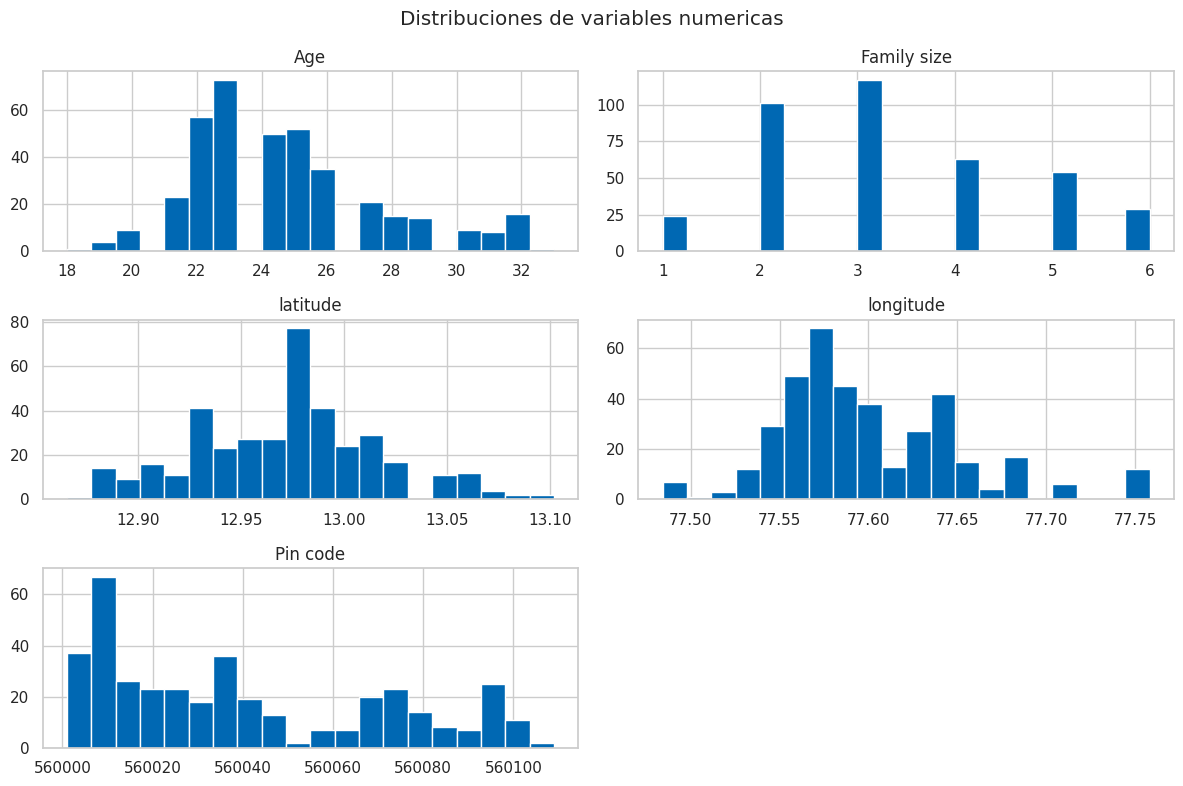

In [ ]:
seleccion_numericas = columnas_numericas[:6]
if seleccion_numericas:
  df[seleccion_numericas].hist(
    bins=20,
    figsize=(12, 8),
    color="#0068B3",
    edgecolor="white"
  )
  plt.suptitle("Distribuciones de variables numericas")
  plt.tight_layout()
  plt.show()


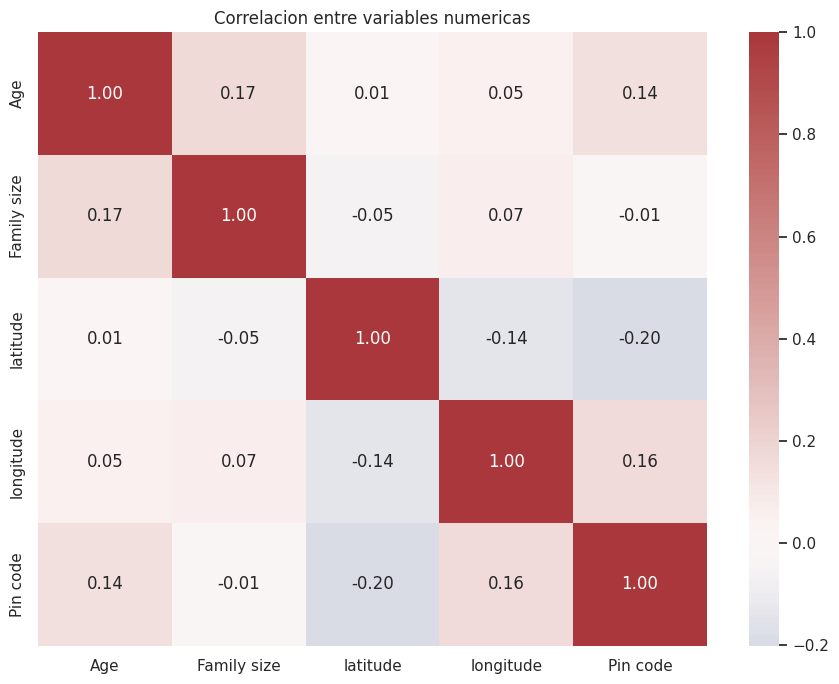

In [ ]:
seleccion_correlacion = columnas_numericas[:8]
if len(seleccion_correlacion) >= 2:
  matriz_correlacion = df[seleccion_correlacion].corr()
  plt.figure(figsize=(9, 7))
  sns.heatmap(
    matriz_correlacion,
    annot=True,
    fmt=".2f",
    cmap="vlag",
    center=0
  )
  plt.title("Correlacion entre variables numericas")
  plt.tight_layout()
  plt.show()


Del mapa de calor de correlación entre las variables numéricas, se puede observar lo siguiente:

Correlación positiva más marcada: La pareja con la correlación positiva más marcada es 'Age' y 'Family size', con un coeficiente de 0.17. Esto significa que a medida que la 'Age' de los clientes tiende a aumentar, su 'Family size' también tiende a ser ligeramente mayor. No implica que la edad cause el tamaño de la familia, sino que estas dos variables tienen una tendencia a variar en la misma dirección.

Correlación negativa más marcada: La pareja con la correlación negativa más marcada es 'Pin code' y 'latitude', con un coeficiente de -0.20. Esto indica que a medida que el 'Pin code' (código postal) tiende a aumentar, la 'latitude' (latitud) de los clientes tiende a disminuir. Es decir, cuando una de estas variables toma un valor más alto, la otra tiende a tomar un valor más bajo. Es importante recordar que esto no es una relación de causa y efecto, sino una asociación observada en los datos.

## Hallazgos principales

Aquí se resumen los hallazgos más relevantes del análisis exploratorio de datos, siguiendo la estructura solicitada:

1.  **Tamaño y Duplicados:**
    *   **Evidencia:** El dataset inicial contenía 388 filas. Se identificaron 103 filas duplicadas, lo que representa un 26.55% del total. Tras la eliminación de duplicados, el dataset resultante tiene 285 filas y 14 columnas.
    *   **Interpretación:** La presencia de un alto porcentaje de duplicados sugiere la necesidad de comprender la naturaleza de los registros. Si cada fila debería ser única (ej. un evento o cliente distinto), entonces su eliminación es apropiada. Si se permite la repetición de atributos para diferentes instancias válidas, entonces no son 'duplicados' en el sentido de error.
    *   **Pregunta Pendiente:** ¿Representan estos duplicados exactos errores de entrada o múltiples interacciones de los mismos clientes/eventos con idénticos atributos, lo cual sería información válida? Se necesita una aclaración sobre la unidad de análisis esperada.

2.  **Valores Nulos:**
    *   **Evidencia:** No se encontraron valores nulos en ninguna de las 14 columnas del dataset.
    *   **Interpretación:** El dataset es excepcionalmente limpio en términos de completitud. Esto es positivo para la calidad de los datos y simplifica el preprocesamiento.
    *   **Pregunta Pendiente:** ¿Qué procesos de recopilación o limpieza de datos se implementaron para asegurar la completa ausencia de valores nulos en todas las columnas? Comprender esto podría ayudar a replicar la calidad en futuros datasets.

3.  **Tipos de Columnas y Semántica:**
    *   **Evidencia:** Se identificaron 5 columnas numéricas (Age, Family size, latitude, longitude, Pin code) y 9 categóricas. La columna 'Pin code', aunque numérica (entera), funciona semánticamente como un identificador geográfico o una categoría, no como un valor cuantitativo.
    *   **Interpretación:** La clasificación de las columnas es crucial para elegir los métodos de análisis y visualización adecuados. Es importante tratar 'Pin code' como una variable categórica para evitar interpretaciones erróneas de sus estadísticas numéricas.
    *   **Pregunta Pendiente:** ¿Existen otras columnas que, aunque Pandas las clasifique de una forma, su significado real sugiera un tipo de tratamiento diferente (ej. ordinales)?

4.  **Distribución de 'Age' (Edad):**
    *   **Evidencia:** La media de la edad es 24.63 años y la mediana es 24.00 años. El 25% de los clientes tienen 23 años o menos, y el 95% tienen 30 años o menos, con un rango total de 18 a 33 años. El histograma muestra una concentración significativa entre los 22 y 25 años.
    *   **Interpretación:** La distribución de la edad es relativamente simétrica, indicando una base de clientes predominantemente joven. La cercanía entre media y mediana confirma la ausencia de un sesgo fuerte o valores atípicos extremos.
    *   **Pregunta Pendiente:** ¿Esta demografía juvenil es un objetivo de mercado específico del servicio de entrega o simplemente refleja la población general de usuarios de plataformas online?

5.  **Distribución y Ausencia de Atípicos en 'Family size':**
    *   **Evidencia:** La media de 'Family size' es 3.28 y la mediana es 3.00. La mayoría de los valores se concentran entre 2 y 3. El diagrama de caja mostró que los bigotes se extienden hasta los valores mínimo (1) y máximo (6), sin detectar valores atípicos.
    *   **Interpretación:** La distribución es aproximadamente simétrica y no presenta valores extremos que se desvíen significativamente del patrón general. Esto sugiere que los tamaños de familia están dentro de un rango esperado y no hay observaciones inusuales que requieran un análisis especial para esta variable.
    *   **Pregunta Pendiente:** ¿Cómo se relaciona el tamaño de la familia con el volumen o la frecuencia de los pedidos, o con el tipo de cliente (ej. 'Frequent' vs 'Regular')?

6.  **Correlaciones entre Variables Numéricas:**
    *   **Evidencia:** La correlación positiva más marcada se observa entre 'Age' y 'Family size' (0.17). La correlación negativa más marcada se encuentra entre 'Pin code' y 'latitude' (-0.20).
    *   **Interpretación:** Existe una ligera tendencia a que los clientes con mayor edad tengan un tamaño de familia un poco más grande. También se observa una leve relación inversa entre el código postal y la latitud. Es importante recordar que estas son asociaciones y no implican causalidad directa.
    *   **Pregunta Pendiente:** ¿Estas correlaciones, aunque débiles, podrían ser útiles para la creación de modelos predictivos o la segmentación de usuarios en combinación con otras variables?

7.  **Columna 'Unnamed: 13':**
    *   **Evidencia:** Esta columna es de tipo categórico y contiene 2 valores únicos.
    *   **Interpretación:** El nombre genérico 'Unnamed: 13' impide entender su significado o relevancia sin información adicional. Es crucial determinar qué tipo de información representa.
    *   **Pregunta Pendiente:** Es indispensable consultar la documentación original del dataset en Kaggle para comprender el significado de la columna 'Unnamed: 13' y decidir si debe incluirse o excluirse del análisis.

## Conclusión sobre la utilidad del dataset

Este dataset podría ser de gran utilidad para responder preguntas descriptivas sobre el perfil demográfico y de comportamiento de los clientes de servicios de entrega de comida, como por ejemplo: "¿Cuál es la composición demográfica (edad, género, ocupación, ingresos) de los clientes que utilizan servicios de entrega de comida, y cómo se relaciona esto con su tipo de cliente y feedback?". Entre sus fortalezas se destaca la ausencia completa de valores nulos, lo que simplifica la etapa de preprocesamiento, y la identificación clara de variables numéricas y categóricas que presentan distribuciones con rangos coherentes. Sin embargo, antes de utilizarlo para construir un modelo, se deben investigar varias dudas: la más crítica es el significado de la columna 'Unnamed: 13', que carece de contexto y podría ser irrelevante o crucial. Además, la presencia de un 26.55% de filas duplicadas requiere una validación con la fuente para determinar si representan errores o interacciones válidas repetidas, ya que esto afecta la integridad del análisis de clientes únicos. Finalmente, la interpretación del 'Pin code', aunque numérico, debe tratarse con precaución como una categoría geográfica en lugar de una medida cuantitativa.

## Autoevaluación: Relación con CRISP-DM

El trabajo realizado en este laboratorio corresponde principalmente a la fase de **Comprensión de los Datos (Data Understanding)** del ciclo de vida CRISP-DM. Esta fase se caracteriza por la recopilación inicial y familiarización con los datos, la identificación de la calidad de los datos, y la formulación de las primeras hipótesis y preguntas que guiarán el análisis. La evidencia de esta correspondencia es abundante y se manifiesta a lo largo de las actividades:

1.  **Revisión de la procedencia y descripción de la fuente:** Se inició con la comprensión del dataset, incluyendo su autor, enlace, unidad de análisis, justificación de la selección y pregunta inicial (celda z0Y3tE9CdF2d), lo cual es un paso fundamental en la Comprensión de los Datos para establecer el contexto del proyecto.
2.  **Identificación de unidad de análisis, columnas y tipos:** Se determinó la cantidad de filas y columnas, la unidad de análisis (experiencia del cliente) y se clasificaron las columnas en numéricas y categóricas, destacando incluso casos donde el tipo de Pandas no coincidía con la semántica (celdas g78UVBOke8Qs, jvseV83jkbDy, lEuVNchQlaAE, kKrx8vTblwOy, HvEFRJ9xM8wd). Esto es central para entender la estructura de los datos.
3.  **Examen de completitud, duplicación y valores distintos:** Se realizó un análisis exhaustivo de la calidad de los datos, verificando la ausencia de valores nulos y detectando un porcentaje significativo de filas duplicadas. Se examinó la cardinalidad de cada columna (df.nunique()) para identificar variables con pocos valores únicos (celdas dYqF1Lg2M_h6, 9q91FI1-Ni94, 3TzHFzWNNkHY, 5QsjAAH_OuSm, A_d2cupsOweF). Estas actividades son cruciales para evaluar la integridad y validez de los datos.
4.  **Descripción de distribuciones, percentiles y categorías:** Se exploraron las distribuciones de variables numéricas mediante estadísticas descriptivas, medias, medianas, percentiles e histogramas (ukSPACfNPPFh,PPgWyGhDPfSY, tlssyARIQpvH, npUPRQt8US9c, NcyoOa6nWjzt). Para las variables categóricas, se analizaron sus frecuencias y porcentajes, y se visualizaron mediante gráficos de barras (I2KekWd2TXvj, 0IWdHtgMWCvQ). También se analizaron las correlaciones entre variables numéricas (riBhUXGIWyp0). Esta exploración visual y estadística es la esencia de la Comprensión de los Datos.
5.  **Formulación de dudas que deben resolverse antes de preparar o modelar:** De manera consistente, se generaron preguntas pendientes sobre la naturaleza de los duplicados, el significado de la columna 'Unnamed: 13', y la interpretación de la demografía del cliente (celdas 77fbf4d6, fc93f5b4). Esto demuestra un análisis crítico y la identificación de aspectos que requerirán mayor investigación o preparación en fases posteriores, consolidando la naturaleza de Comprensión de los Datos de este laboratorio.